# Metrics comparison between IK control solutions with teleoperation motions

Data processing notebook for motions with the following script:

* [`live_data.py`](https://github.com/pollen-robotics/reachy2_qpik/blob/develop/src/example/live_data.py)

The CSV files are stored in the [data/teleop/](https://github.com/pollen-robotics/reachy2_qpik/tree/develop/src/example/data/teleop) folder.

## Imports 

In [6]:
import ast
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from metrics import l2_error, rodrigues_error
from reachy2_symbolic_ik.symbolic_ik import SymbolicIK
from reachy2_sdk import ReachySDK
from pathlib import Path
from typing import Union, Iterable, List
from tqdm.notebook import tqdm
import logging

In [7]:
symbolic_l = SymbolicIK(arm="l_arm")
symbolic_r = SymbolicIK(arm="r_arm")


logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

Using default parameters
Using default parameters


## Utility functions

In [8]:
def parse_pose_matrix(matrix):
    """Convert a string of a matrix into a NumPy array."""
    if isinstance(matrix, str):
        return np.array(ast.literal_eval(matrix))
    else:
        return np.array(matrix)


def pose_matrix_to_goal(pose_mat):
    """
    pose_mat: 4x4 numpy array
    returns: np.array([position_list, [roll, pitch, yaw]]) where angles in radians
    """
    R = pose_mat[:3, :3]
    t = pose_mat[:3, 3].tolist()

    sy = math.sqrt(R[0, 0] ** 2 + R[1, 0] ** 2)
    singular = sy < 1e-6

    if not singular:
        roll = math.atan2(R[2, 1], R[2, 2])
        pitch = math.atan2(-R[2, 0], sy)
        yaw = math.atan2(R[1, 0], R[0, 0])
    else:
        roll = math.atan2(-R[1, 2], R[1, 1])
        pitch = math.atan2(-R[2, 0], sy)
        yaw = 0.0

    return np.array([t, [roll, pitch, yaw]], dtype=float)


def compute_fk_l(reachy, row):
    joints = np.rad2deg([row[f"l_q{i}"] for i in range(7)])
    M = reachy.l_arm.forward_kinematics(joints)
    return M.tolist()


def compute_fk_r(reachy, row):
    joints = np.rad2deg([row[f"r_q{i}"] for i in range(7)])
    M = reachy.r_arm.forward_kinematics(joints)
    return M.tolist()


def row_is_reachable_by_symbolic_ik(row, symbolic_l=symbolic_l, symbolic_r=symbolic_r):
    """
    Returns True if both (existing) left and right goals in the row are reachable
    according to the Symbolic IK.
    """
    reachable_l = True
    reachable_r = True

    if "l_pose" in row.index and str(row["l_pose"]) != "None":
        try:
            l_pose_mat = parse_pose_matrix(row["l_pose"])
            goal_l = pose_matrix_to_goal(l_pose_mat)
            is_reachable_l, _, _, _ = symbolic_l.is_reachable(goal_l)
            reachable_l = bool(is_reachable_l)
        except Exception as e:
            reachable_l = False

    if "r_pose" in row.index and str(row["r_pose"]) != "None":
        try:
            r_pose_mat = parse_pose_matrix(row["r_pose"])
            goal_r = pose_matrix_to_goal(r_pose_mat)
            is_reachable_r, _, _, _ = symbolic_r.is_reachable(goal_r)
            reachable_r = bool(is_reachable_r)
        except Exception as e:
            reachable_r = False

    return reachable_l and reachable_r


def compute_errors(df, lambda_theta=1e-6 / np.deg2rad(1) ** 2):
    if "l_pos_err" in df.columns and "r_pos_err" in df.columns:
        df["l_comb_err"] = np.sqrt(df["l_pos_err"] ** 2 + (lambda_theta * df["l_rot_err"] ** 2))
        df["r_comb_err"] = np.sqrt(df["r_pos_err"] ** 2 + (lambda_theta * df["r_rot_err"] ** 2))
        return df

    l_pos_errs, l_rot_errs = [], []
    r_pos_errs, r_rot_errs = [], []

    for _, row in df.iterrows():
        try:
            l_pose = parse_pose_matrix(row["l_pose"]) if row["l_pose"] != "None" else None
        except Exception:
            l_pose = None
        l_real = parse_pose_matrix(row["l_real_pose"])
        if l_pose is not None:
            l_pos_errs.append(l2_error(l_pose[:3, 3], l_real[:3, 3]))
            l_rot_errs.append(rodrigues_error(l_pose[:3, :3], l_real[:3, :3]))
        else:
            l_pos_errs.append(np.nan)
            l_rot_errs.append(np.nan)

        try:
            r_pose = parse_pose_matrix(row["r_pose"]) if row["r_pose"] != "None" else None
        except Exception:
            r_pose = None
        r_real = parse_pose_matrix(row["r_real_pose"])
        if r_pose is not None:
            r_pos_errs.append(l2_error(r_pose[:3, 3], r_real[:3, 3]))
            r_rot_errs.append(rodrigues_error(r_pose[:3, :3], r_real[:3, :3]))
        else:
            r_pos_errs.append(np.nan)
            r_rot_errs.append(np.nan)

    df["l_pos_err"] = l_pos_errs
    df["l_rot_err"] = l_rot_errs
    df["r_pos_err"] = r_pos_errs
    df["r_rot_err"] = r_rot_errs
    df["l_comb_err"] = np.sqrt(df["l_pos_err"] ** 2 + (lambda_theta * df["l_rot_err"] ** 2))
    df["r_comb_err"] = np.sqrt(df["r_pos_err"] ** 2 + (lambda_theta * df["r_rot_err"] ** 2))
    return df


def compute_reachability_flags(df, symbolic_l=symbolic_l, symbolic_r=symbolic_r):
    l_flags, r_flags = [], []
    for _, row in df.iterrows():
        reachable_l = False
        if "l_pose" in row.index and str(row["l_pose"]) != "None":
            try:
                l_pose_mat = parse_pose_matrix(row["l_pose"])
                goal_l = pose_matrix_to_goal(l_pose_mat)
                is_reachable_l, _, _, _ = symbolic_l.is_reachable(goal_l)
                reachable_l = bool(is_reachable_l)
            except Exception:
                reachable_l = False
        else:
            reachable_l = False

        reachable_r = False
        if "r_pose" in row.index and str(row["r_pose"]) != "None":
            try:
                r_pose_mat = parse_pose_matrix(row["r_pose"])
                goal_r = pose_matrix_to_goal(r_pose_mat)
                is_reachable_r, _, _, _ = symbolic_r.is_reachable(goal_r)
                reachable_r = bool(is_reachable_r)
            except Exception:
                reachable_r = False
        else:
            reachable_r = False

        l_flags.append(reachable_l)
        r_flags.append(reachable_r)

    df = df.copy()
    df["l_reachable"] = np.array(l_flags, dtype=bool)
    df["r_reachable"] = np.array(r_flags, dtype=bool)
    return df


def process_teleop_file(filepath: Union[str, Path], reachy, save_dir: Union[str, Path]) -> Path:
    """Compute real poses for the provided CSV file."""

    filepath = Path(filepath)
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    logger.info(f"Processing {filepath.name} ...")
    df = pd.read_csv(filepath, sep=",", header=0).copy()
    df = df.dropna().reset_index(drop=True)

    l_poses: List = []
    r_poses: List = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"FK {filepath.name}", leave=False):
        try:
            l = compute_fk_l(reachy, row)
            r = compute_fk_r(reachy, row)
        except Exception as e:
            logger.warning(f"{filepath.name}: Error while computing FK -> {e}")
        l_poses.append(l)
        r_poses.append(r)

    df["l_real_pose"] = l_poses
    df["r_real_pose"] = r_poses

    out_name = filepath.stem + "_postprocessed.csv"
    out_path = save_dir / out_name
    df.to_csv(out_path, index=False)
    logger.info(f"Saved postprocessed file -> {out_path}")
    return out_path


def postprocess_teleop(
    reachy: ReachySDK,
    filenames: Union[None, str, Iterable[str]] = None,
    teleop_dir: Union[str, Path] = "data/teleop",
    post_dirname: str = "postprocessed",
) -> List[Path]:
    """Compute and save preprocessed file in the provided folder."""

    teleop_dir = Path(teleop_dir)
    post_dir = teleop_dir / post_dirname
    post_dir.mkdir(parents=True, exist_ok=True)

    if filenames is None:
        files = [p for p in teleop_dir.glob("*.csv") if p.parent == teleop_dir]
    else:
        if isinstance(filenames, (str, Path)):
            files = [Path(filenames)]
        else:
            files = [Path(f) for f in filenames]

    saved_paths: List[Path] = []
    try:
        for p in files:
            out = process_teleop_file(p, reachy, post_dir)
            saved_paths.append(out)
    finally:
        reachy.disconnect()

    return saved_paths

## Position comparison between Desired pose and Real pose  

The `postprocess_teleop(reachy, filepath)` function applies forward kinematics to the joints to extract their poses. The new file will be saved in the [teleop/postprocessed/](https://github.com/pollen-robotics/reachy2_qpik/tree/develop/src/example/data/teleop) folder in the format “filename_postprocessed.csv.”

### _Important: Running the postprocessing cells requires a connection to a simulated robot (e.g., in RViZ)._


In [9]:
filepath = "data/teleop/sym_heart_live.csv"

reachy = ReachySDK(host="localhost")
processed_filepath = postprocess_teleop(reachy, filepath)

INFO: Connected to Reachy.
INFO: Processing sym_heart_live.csv ...


FK sym_heart_live.csv:   0%|          | 0/3953 [00:00<?, ?it/s]

INFO: Saved postprocessed file -> data/teleop/postprocessed/sym_heart_live_postprocessed.csv
INFO: Disconnected from Reachy.


### Display plot

The observed coordinate (X, Y, Z) and time window can be adjusted.

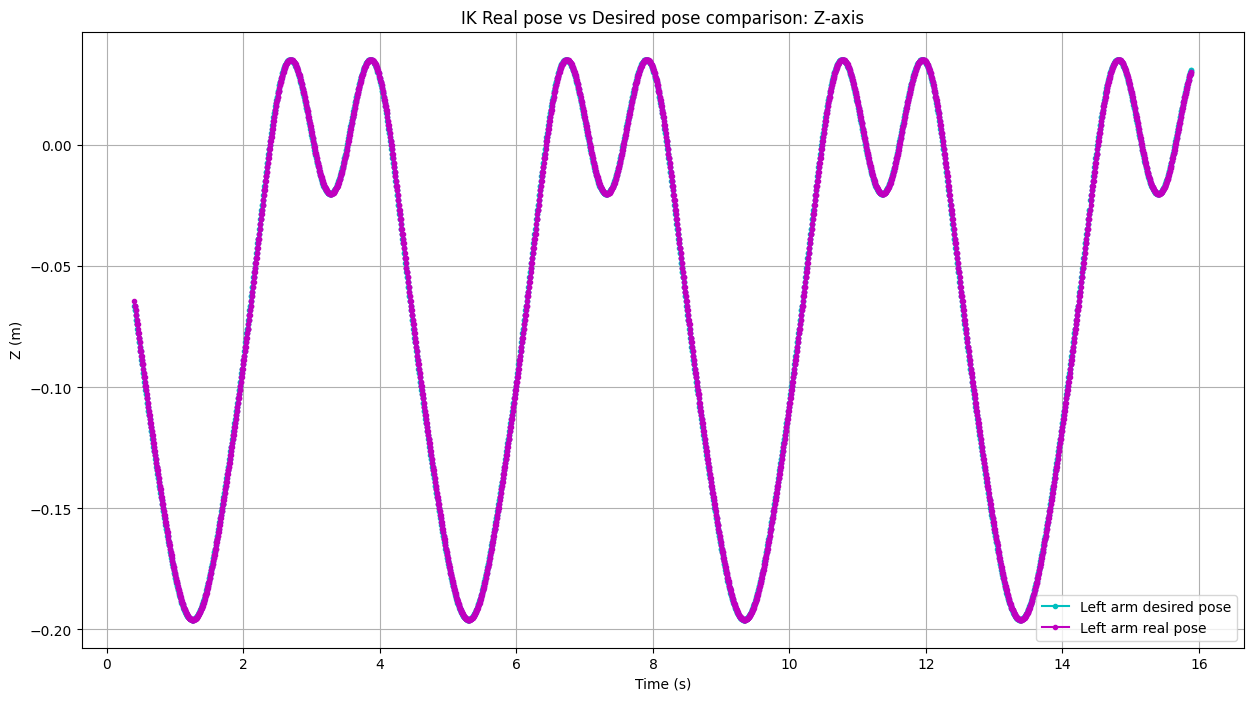

In [30]:
processed_filepath = "data/teleop/postprocessed/sym_heart_live_postprocessed.csv"
df = pd.read_csv(processed_filepath, sep=",", header=0).copy()

coord_idx = 2  # 0, 1, 2 for X, Y, Z

a, b = 100, None
pose_slice = slice(a, None if b is None else b - 1)
time_slice = slice(a + 1, None if b is None else b)

plt.figure(figsize=(15, 8))
L_POSE_LST = []
L_POSE_REAL_LST = []
for i in range(1, len(df)):
    l_pose = parse_pose_matrix(df["l_pose"][i])[coord_idx][3]
    l_pose_real = parse_pose_matrix(df["l_real_pose"][i])[coord_idx][3]
    L_POSE_LST.append(l_pose)
    L_POSE_REAL_LST.append(l_pose_real)
plt.plot(df["time"][time_slice], L_POSE_LST[pose_slice], label="Left arm desired pose", color="c", marker=".")
plt.plot(df["time"][time_slice], L_POSE_REAL_LST[pose_slice], label="Left arm real pose", color="m", marker=".")
plt.grid()
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel(f"{"XYZ"[coord_idx]} (m)")
plt.title(f"IK Real pose vs Desired pose comparison: {"XYZ"[coord_idx]}-axis")
plt.show()

## IK control solutions comparison

### Computing Real poses

In [11]:
reachy = ReachySDK(host="localhost")
processed_filepaths = postprocess_teleop(reachy)
print(processed_filepaths)

INFO: Connected to Reachy.
INFO: Processing num_heart_live.csv ...


FK num_heart_live.csv:   0%|          | 0/3857 [00:00<?, ?it/s]

INFO: Saved postprocessed file -> data/teleop/postprocessed/num_heart_live_postprocessed.csv
INFO: Processing sym_basket_grab.csv ...


FK sym_basket_grab.csv:   0%|          | 0/6803 [00:00<?, ?it/s]

INFO: Saved postprocessed file -> data/teleop/postprocessed/sym_basket_grab_postprocessed.csv
INFO: Processing sym_spill.csv ...


...

FK qp_basket_grab.csv:   0%|          | 0/7091 [00:00<?, ?it/s]

INFO: Saved postprocessed file -> data/teleop/postprocessed/qp_basket_grab_postprocessed.csv
INFO: Processing num_basket_grab.csv ...


FK num_basket_grab.csv:   0%|          | 0/7339 [00:00<?, ?it/s]

INFO: Saved postprocessed file -> data/teleop/postprocessed/num_basket_grab_postprocessed.csv
INFO: Disconnected from Reachy.


[PosixPath('data/teleop/postprocessed/num_heart_live_postprocessed.csv'), PosixPath('data/teleop/postprocessed/sym_basket_grab_postprocessed.csv'), PosixPath('data/teleop/postprocessed/sym_spill_postprocessed.csv'), PosixPath('data/teleop/postprocessed/sym_grabbing_object_postprocessed.csv'), PosixPath('data/teleop/postprocessed/qp_spill_postprocessed.csv'), PosixPath('data/teleop/postprocessed/qp_grabbing_object_postprocessed.csv'), PosixPath('data/teleop/postprocessed/sym_circle_live_postprocessed.csv'), PosixPath('data/teleop/postprocessed/qp_hello_world_postprocessed.csv'), PosixPath('data/teleop/postprocessed/qp_heart_live_postprocessed.csv'), PosixPath('data/teleop/postprocessed/num_circle_live_postprocessed.csv'), PosixPath('data/teleop/postprocessed/num_hello_world_postprocessed.csv'), PosixPath('data/teleop/postprocessed/sym_heart_live_postprocessed.csv'), PosixPath('data/teleop/postprocessed/num_spill_postprocessed.csv'), PosixPath('data/teleop/postprocessed/qp_circle_live_po

### Metrics comparison plot

The poses are filtered with inverse kinematics to verify their unreachability.

In [23]:
test = "spill"
paths = {
    "Symbolic IK": f"data/teleop/postprocessed/sym_{test}_postprocessed.csv",
    "Jacobian IK": f"data/teleop/postprocessed/num_{test}_postprocessed.csv",
    "QP IK": f"data/teleop/postprocessed/qp_{test}_postprocessed.csv",
}

lambda_theta = 1e-6 / np.deg2rad(1) ** 2

dfs_dict = {}
for name, p in paths.items():
    df_tmp = pd.read_csv(p, sep=",", header=0).copy().dropna().reset_index(drop=True)
    df_tmp = compute_errors(df_tmp)
    dfs_dict[name] = df_tmp

order = ["Symbolic IK", "Jacobian IK", "QP IK"]
dfs_list = [(dfs_dict[name], name) for name in order]


for i, (df_tmp, title) in enumerate(dfs_list):
    dfs_list[i] = (compute_reachability_flags(df_tmp), title)

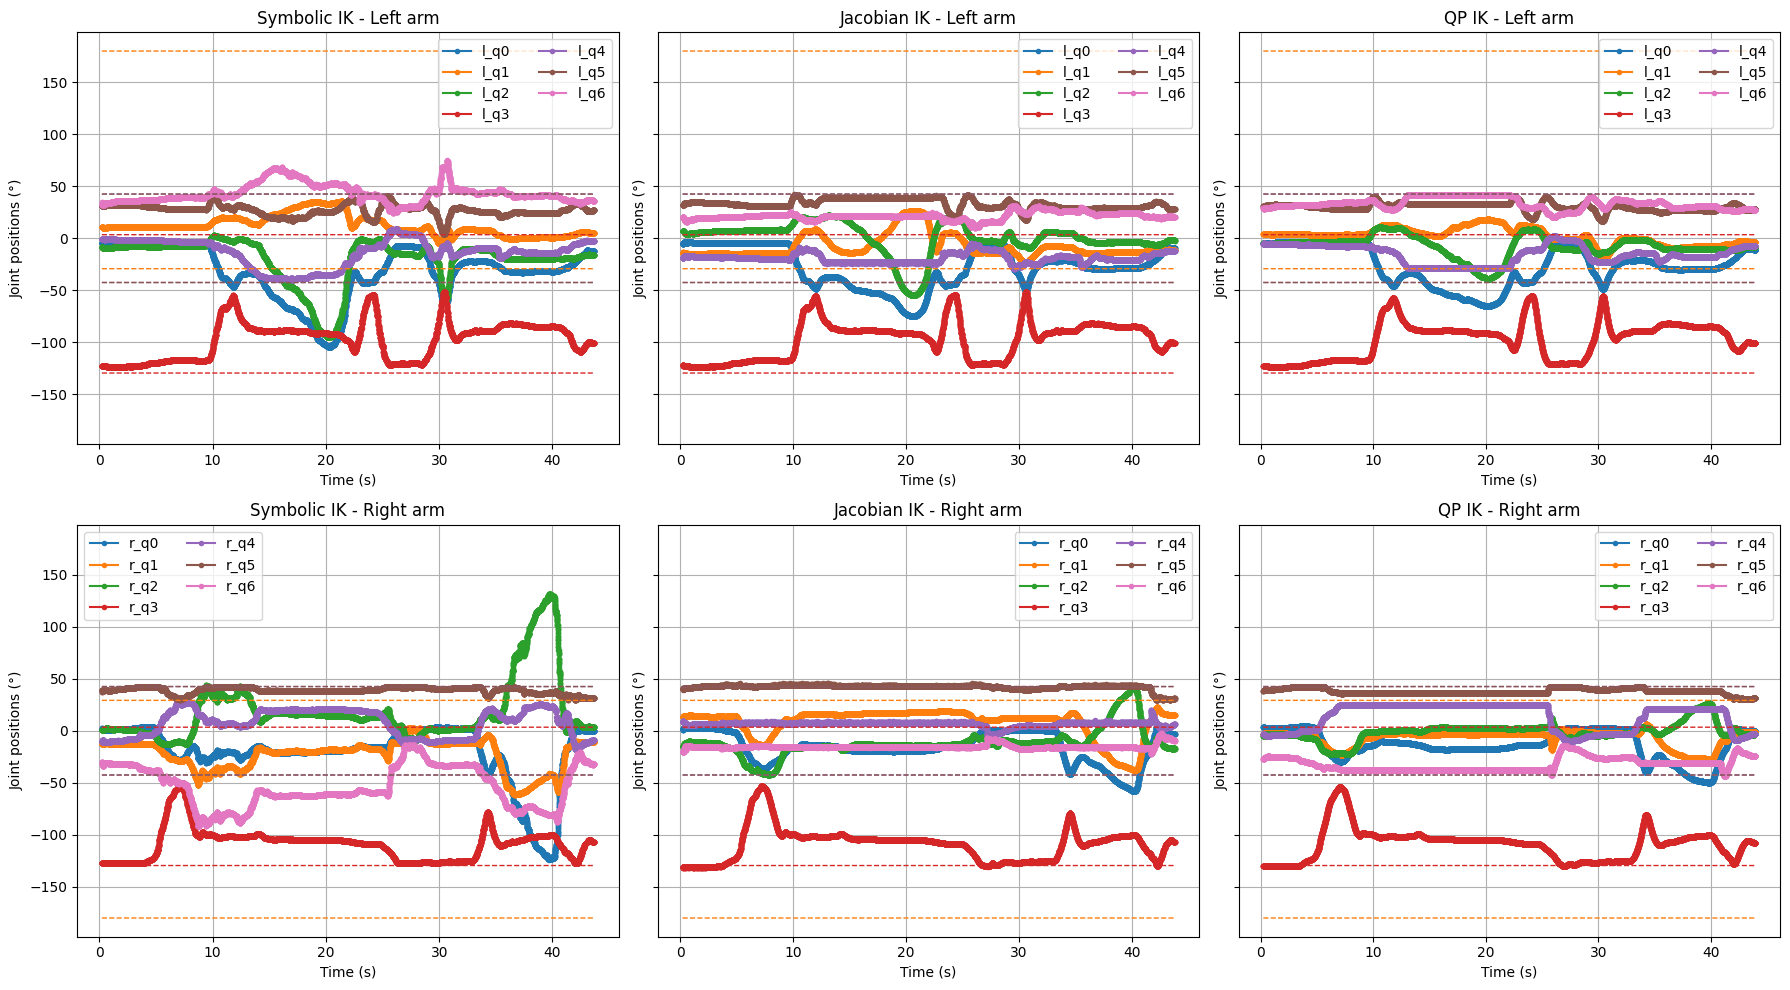

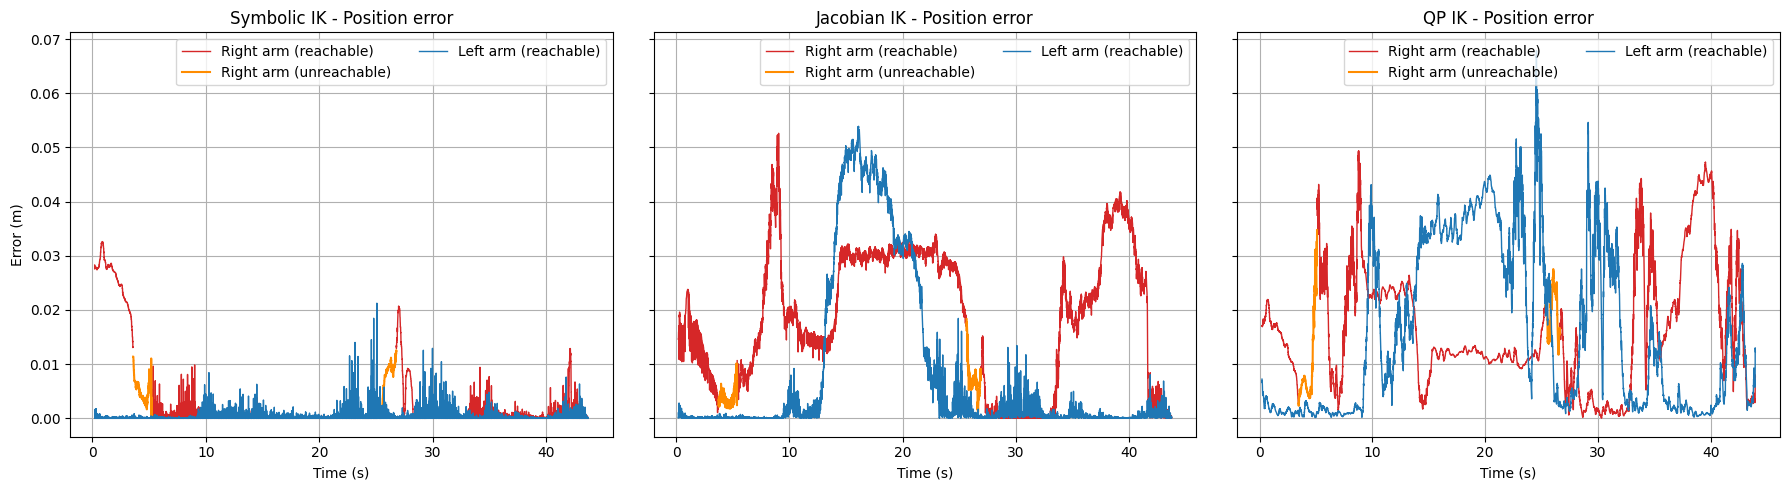

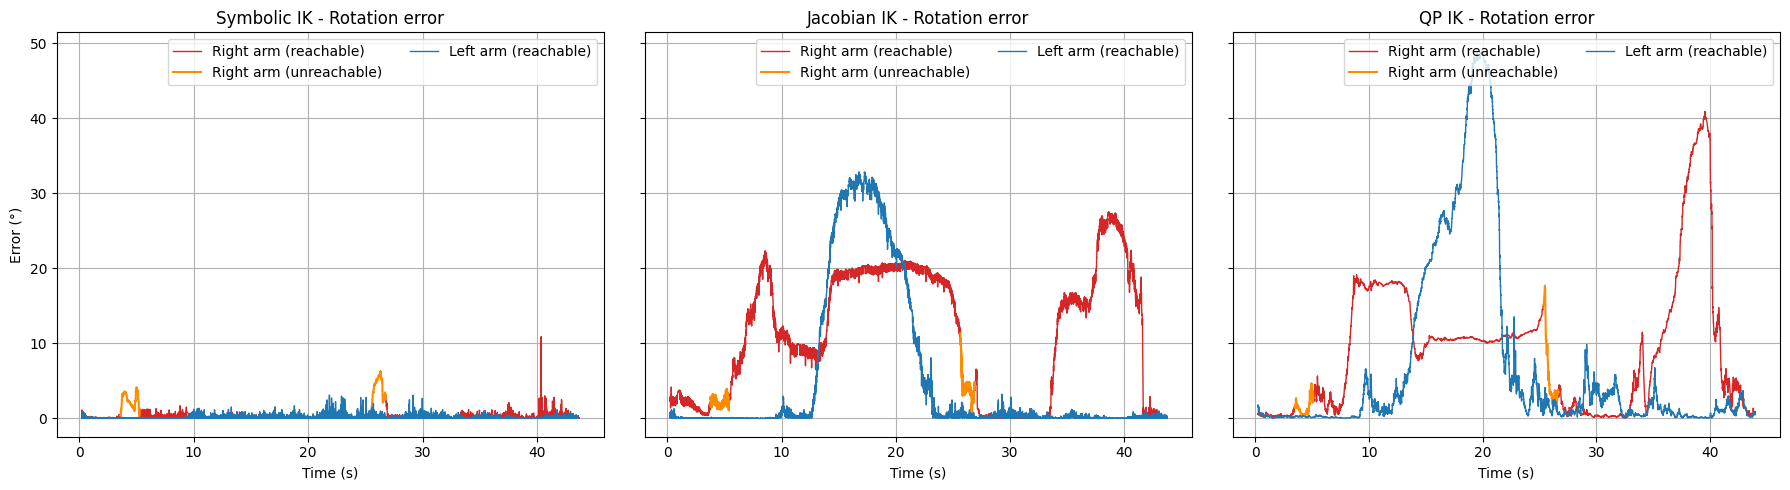

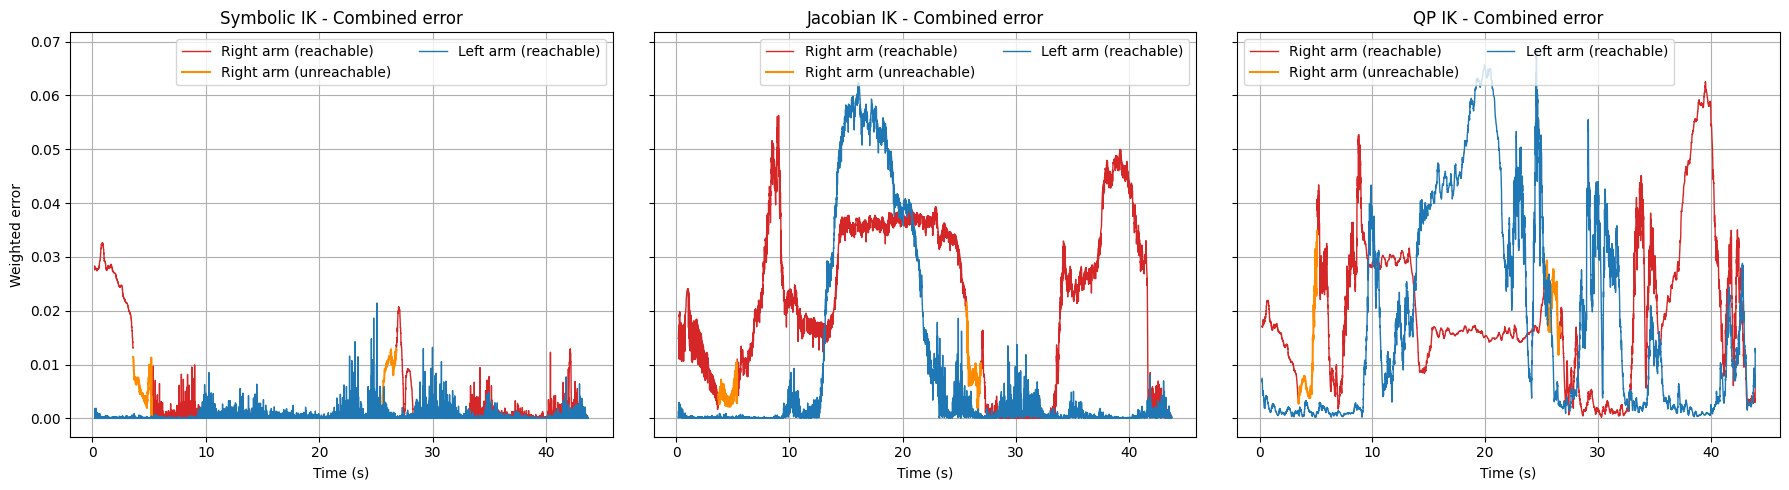

In [24]:
time_slice = slice(50, None)

l_cols = [f"l_q{i}" for i in range(7)]
r_cols = [f"r_q{i}" for i in range(7)]

q_min_l = np.array([-10000.0, -0.51, -10000.0, -2.26, -0.7417649320975901, -0.7417649320975901, -10000.0])
q_max_l = np.array([10000.0, 3.14, 10000.0, 0.06, 0.7417649320975901, 0.7417649320975901, 10000.0])

q_min_r = np.array([-10000.0, -3.14, -10000.0, -2.26, -0.7417649320975901, -0.7417649320975901, -10000.0])
q_max_r = np.array([10000.0, 0.51, 10000.0, 0.06, 0.7417649320975901, 0.7417649320975901, 10000.0])

q_min_l_deg = np.rad2deg(q_min_l)
q_max_l_deg = np.rad2deg(q_max_l)
q_min_r_deg = np.rad2deg(q_min_r)
q_max_r_deg = np.rad2deg(q_max_r)

skip_idxs = {0, 2, 6}

base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
colors = [base_colors[i % len(base_colors)] for i in range(7)]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey="row")
for idx, (df_tmp, title) in enumerate(dfs_list):
    for j, col in enumerate(l_cols):
        if col in df_tmp.columns:
            axes[0, idx].plot(
                df_tmp["time"][time_slice],
                np.rad2deg(df_tmp[col][time_slice].to_numpy()),
                marker=".",
                label=col,
                color=colors[j],
            )
    axes[0, idx].set_title(f"{title} - Left arm")
    axes[0, idx].set_xlabel("Time (s)")
    axes[0, idx].set_ylabel("Joint positions (°)")
    axes[0, idx].grid(True)
    axes[0, idx].legend(ncol=2)

    for j, col in enumerate(r_cols):
        if col in df_tmp.columns:
            axes[1, idx].plot(
                df_tmp["time"][time_slice],
                np.rad2deg(df_tmp[col][time_slice].to_numpy()),
                marker=".",
                label=col,
                color=colors[j],
            )
    axes[1, idx].set_title(f"{title} - Right arm")
    axes[1, idx].set_xlabel("Time (s)")
    axes[1, idx].set_ylabel("Joint positions (°)")
    axes[1, idx].grid(True)
    axes[1, idx].legend(ncol=2)

    vals = []
    for j, col in enumerate(l_cols):
        if col in df_tmp.columns:
            arr = np.rad2deg(df_tmp[col][time_slice].to_numpy())
            arr = arr[np.isfinite(arr)]
            if arr.size:
                vals.append(arr.min())
                vals.append(arr.max())
    for j, col in enumerate(r_cols):
        if col in df_tmp.columns:
            arr = np.rad2deg(df_tmp[col][time_slice].to_numpy())
            arr = arr[np.isfinite(arr)]
            if arr.size:
                vals.append(arr.min())
                vals.append(arr.max())
    for j in range(7):
        if j in skip_idxs:
            continue
        vals.append(q_min_l_deg[j])
        vals.append(q_max_l_deg[j])
        vals.append(q_min_r_deg[j])
        vals.append(q_max_r_deg[j])

    if vals:
        ymin = min(vals)
        ymax = max(vals)
        yrange = ymax - ymin if ymax != ymin else abs(ymax) + 1.0
        pad = 0.05 * yrange
        axes[0, idx].set_ylim(ymin - pad, ymax + pad)
        axes[1, idx].set_ylim(ymin - pad, ymax + pad)

    t = df_tmp["time"][time_slice].to_numpy()
    for j in range(7):
        if j in skip_idxs:
            continue
        col_color = colors[j]
        axes[0, idx].plot(t, np.full_like(t, q_min_l_deg[j]), linestyle="--", linewidth=1, color=col_color, label="_nolegend_")
        axes[0, idx].plot(t, np.full_like(t, q_max_l_deg[j]), linestyle="--", linewidth=1, color=col_color, label="_nolegend_")

        axes[1, idx].plot(t, np.full_like(t, q_min_r_deg[j]), linestyle="--", linewidth=1, color=col_color, label="_nolegend_")
        axes[1, idx].plot(t, np.full_like(t, q_max_r_deg[j]), linestyle="--", linewidth=1, color=col_color, label="_nolegend_")

fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for idx, (df_tmp, title) in enumerate(dfs_list):
    sub = df_tmp.iloc[time_slice].reset_index(drop=True)
    t = sub["time"].to_numpy()

    r_err = sub["r_pos_err"].to_numpy()
    l_err = sub["l_pos_err"].to_numpy()

    unreachable_r = ~sub["r_reachable"].to_numpy(dtype=bool)
    unreachable_l = ~sub["l_reachable"].to_numpy(dtype=bool)

    r_reachable_only = np.where(unreachable_r, np.nan, r_err)
    r_unreachable_only = np.where(unreachable_r, r_err, np.nan)

    l_reachable_only = np.where(unreachable_l, np.nan, l_err)
    l_unreachable_only = np.where(unreachable_l, l_err, np.nan)

    axes[idx].plot(t, r_reachable_only, label="Right arm (reachable)", linestyle="-", linewidth=1, color="tab:red")
    if np.isfinite(r_unreachable_only).any():
        axes[idx].plot(t, r_unreachable_only, label="Right arm (unreachable)", linestyle="-", linewidth=1.5, color="darkorange")

    axes[idx].plot(t, l_reachable_only, label="Left arm (reachable)", linestyle="-", linewidth=1, color="tab:blue")
    if np.isfinite(l_unreachable_only).any():
        axes[idx].plot(t, l_unreachable_only, label="Left arm (unreachable)", linestyle="-", linewidth=1.5, color="deepskyblue")

    axes[idx].set_title(f"{title} - Position error")
    axes[idx].set_xlabel("Time (s)")
    if idx == 0:
        axes[idx].set_ylabel("Error (m)")
    axes[idx].legend(ncol=2)
    axes[idx].grid(True)
fig.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for idx, (df_tmp, title) in enumerate(dfs_list):
    sub = df_tmp.iloc[time_slice].reset_index(drop=True)
    t = sub["time"].to_numpy()

    r_rot = np.rad2deg(sub["r_rot_err"].to_numpy())
    l_rot = np.rad2deg(sub["l_rot_err"].to_numpy())

    unreachable_r = ~sub["r_reachable"].to_numpy(dtype=bool)
    unreachable_l = ~sub["l_reachable"].to_numpy(dtype=bool)

    r_reachable_only = np.where(unreachable_r, np.nan, r_rot)
    r_unreachable_only = np.where(unreachable_r, r_rot, np.nan)

    l_reachable_only = np.where(unreachable_l, np.nan, l_rot)
    l_unreachable_only = np.where(unreachable_l, l_rot, np.nan)

    axes[idx].plot(t, r_reachable_only, label="Right arm (reachable)", linestyle="-", linewidth=1, color="tab:red")
    if np.isfinite(r_unreachable_only).any():
        axes[idx].plot(t, r_unreachable_only, label="Right arm (unreachable)", linestyle="-", linewidth=1.5, color="darkorange")

    axes[idx].plot(t, l_reachable_only, label="Left arm (reachable)", linestyle="-", linewidth=1, color="tab:blue")
    if np.isfinite(l_unreachable_only).any():
        axes[idx].plot(t, l_unreachable_only, label="Left arm (unreachable)", linestyle="-", linewidth=1.5, color="deepskyblue")

    axes[idx].set_title(f"{title} - Rotation error")
    axes[idx].set_xlabel("Time (s)")
    if idx == 0:
        axes[idx].set_ylabel("Error (°)")
    axes[idx].legend(ncol=2)
    axes[idx].grid(True)
fig.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for idx, (df_tmp, title) in enumerate(dfs_list):
    sub = df_tmp.iloc[time_slice].reset_index(drop=True)
    t = sub["time"].to_numpy()

    comb_l = np.sqrt(sub["l_pos_err"].to_numpy() ** 2 + (lambda_theta * sub["l_rot_err"].to_numpy() ** 2))
    comb_r = np.sqrt(sub["r_pos_err"].to_numpy() ** 2 + (lambda_theta * sub["r_rot_err"].to_numpy() ** 2))

    unreachable_r = ~sub["r_reachable"].to_numpy(dtype=bool)
    unreachable_l = ~sub["l_reachable"].to_numpy(dtype=bool)

    r_reachable_only = np.where(unreachable_r, np.nan, comb_r)
    r_unreachable_only = np.where(unreachable_r, comb_r, np.nan)

    l_reachable_only = np.where(unreachable_l, np.nan, comb_l)
    l_unreachable_only = np.where(unreachable_l, comb_l, np.nan)

    axes[idx].plot(t, r_reachable_only, label="Right arm (reachable)", linestyle="-", linewidth=1, color="tab:red")
    if np.isfinite(r_unreachable_only).any():
        axes[idx].plot(t, r_unreachable_only, label="Right arm (unreachable)", linestyle="-", linewidth=1.5, color="darkorange")

    axes[idx].plot(t, l_reachable_only, label="Left arm (reachable)", linestyle="-", linewidth=1, color="tab:blue")
    if np.isfinite(l_unreachable_only).any():
        axes[idx].plot(t, l_unreachable_only, label="Left arm (unreachable)", linestyle="-", linewidth=1.5, color="deepskyblue")

    axes[idx].set_title(f"{title} - Combined error")
    axes[idx].set_xlabel("Time (s)")
    if idx == 0:
        axes[idx].set_ylabel("Weighted error")
    axes[idx].legend(ncol=2)
    axes[idx].grid(True)
fig.tight_layout()
plt.show()